In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 

# Define path that contains some junction files (only 2 files are used for this example, corresponding to 2 individual cells)
juncs_path = "/commons/projects/knowles_singlecell_splicing/bulk_whole_mouse/junctions/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

The junctions are loaded from the following path: /commons/projects/knowles_singlecell_splicing/bulk_whole_mouse/junctions/
The files in the path are: ['SRR26643415_junctions.bed', 'SRR26643420_junctions.bed']


In [4]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.clustering.find_intron_clusters import read_junction_files

# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = juncs_path

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf" 

# define additional parameters 
sequencing_type = "bulk"

output_path = "/commons/projects/knowles_singlecell_splicing/bulk_whole_mouse/Leaflet/"
# ensure output files are to be saved in output_path 
output_file =  output_path + "bulk_intron_clusters"
junc_bed_file= output_path + "bulk_juncs.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*_junctions.bed" # depends on how you ran regtools file is SRR26643420_junctions.bed

In [18]:
junc_file="/commons/projects/knowles_singlecell_splicing/bulk_whole_mouse/junctions/SRR26643420_junctions.bed"

In [19]:
all_juncs_df = find_intron_clusters(junc_files=junc_file, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons, min_num_cells_wjunc=1, 
                       junc_suffix=junc_suffix, filter_shared_ss=False,
                       run_notebook = True)

Loading files obtained from bulk sequencing


100%|██████████| 1/1 [00:00<00:00,  3.33it/s]


The gtf file you provided is /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 43.21 seconds
The number of unique exons is 437943
The number of unique transcript ids is 135995
The number of unique gene ids is 54446
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
The number of junctions after filtering for intron length is 186778
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 139850
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 134467
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 122768
The number of junctions after removing singletons is 18158
The number of clusters after removing singletons is 6459
The number of junctions after gtf file mapping 18158
The number of clusters after filtering for shared splice sites is 6459
The number of junctions after filtering for shared splice sites is 18158
Refining i

In [20]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

      chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
14444     7     140074.100   140082.461      -           8361            85   
14446     7     140081.538   140082.461      -            923             5   
14443     7     140074.100   140082.092      -           7992            75   
14445     7     140081.538   140082.092      -            554             7   
14442     7     140074.100   140081.380      -           7280             9   

         Start_b       End_b               exon_id  
14444  140073.94  140074.100  ENSMUSE00000150978.3  
14446  140081.38  140081.538  ENSMUSE00000899168.1  
14443  140073.94  140074.100  ENSMUSE00000150978.3  
14445  140081.38  140081.538  ENSMUSE00000899168.1  
14442  140073.94  140074.100  ENSMUSE00000150978.3  
The junction of interest is 7_140074100_140081380


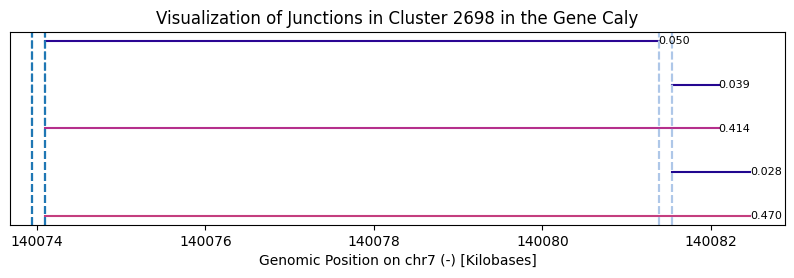

In [21]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [22]:
len(all_juncs_df.gene_id.unique())

4409

In [23]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = all_juncs_df.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 2.7984629861982433


In [17]:
#genes1 = all_juncs_df.gene_id.unique()

In [24]:
genes2 = all_juncs_df.gene_id.unique()

In [25]:
# how many genes do genes1 and genes2 share? 
len(set(genes1).intersection(set(genes2)))

3274

In [28]:
set(genes1).intersection(set(genes2))

{'ENSMUSG00000030410.16',
 'ENSMUSG00000109324.2',
 'ENSMUSG00000033382.14',
 'ENSMUSG00000027304.9',
 'ENSMUSG00000028525.16',
 'ENSMUSG00000028803.18',
 'ENSMUSG00000031760.9',
 'ENSMUSG00000015961.8',
 'ENSMUSG00000031728.10',
 'ENSMUSG00000040842.17',
 'ENSMUSG00000026489.13',
 'ENSMUSG00000034621.14',
 'ENSMUSG00000032816.15',
 'ENSMUSG00000039656.16',
 'ENSMUSG00000036572.16',
 'ENSMUSG00000029053.16',
 'ENSMUSG00000061080.11',
 'ENSMUSG00000040570.14',
 'ENSMUSG00000046329.14',
 'ENSMUSG00000039176.17',
 'ENSMUSG00000032425.15',
 'ENSMUSG00000026087.11',
 'ENSMUSG00000040760.11',
 'ENSMUSG00000015149.14',
 'ENSMUSG00000063052.9',
 'ENSMUSG00000054162.15',
 'ENSMUSG00000060036.14',
 'ENSMUSG00000028822.11',
 'ENSMUSG00000027523.19',
 'ENSMUSG00000020776.18',
 'ENSMUSG00000078517.12',
 'ENSMUSG00000033569.17',
 'ENSMUSG00000032869.15',
 'ENSMUSG00000033543.17',
 'ENSMUSG00000030329.11',
 'ENSMUSG00000041115.16',
 'ENSMUSG00000022494.15',
 'ENSMUSG00000022217.14',
 'ENSMUSG00000023